Adding GDP

In [1]:
# RF_v4: Random Forest with storm/weather/spatial features + county GDP.
# Unit: one row per event-county window.
# Target: t90, from event_start to last downward crossing of outage threshold.
# Evaluation: leave-one-storm-out cross-validation, using global MAE/RMSE.

import os
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [2]:
rf_v3_path = r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\event_level_dataset_rf_v3.csv"

event_df = pd.read_csv(rf_v3_path)

event_df["CountyFIPS"] = event_df["CountyFIPS"].astype(str).str.zfill(5)

if "event_start" not in event_df.columns:
    event_df["event_start"] = pd.to_datetime(event_df["event_id"].str.split("_").str[1])
else:
    event_df["event_start"] = pd.to_datetime(event_df["event_start"])

event_df["year"] = event_df["event_start"].dt.year

print("Event dataset:", event_df.shape)
print(event_df.columns.tolist())
print(event_df[["event_id", "CountyFIPS", "storm", "year", "t90"]].head())

Event dataset: (90, 17)
['event_id', 'storm', 'CountyFIPS', 't90', 't90_censored', 'max_gust', 'mean_gust_7d', 'total_precip_7d', 'pressure_min_7d', 'max_customers_tracked', 'county_pop', 'event_start', 'min_dist_to_storm_km', 'matched_ibtracs_storm', 'storm_max_wind_center_in_conus_mps', 'storm_max_wind_near_conus_mps', 'year']
                            event_id CountyFIPS          storm  year  \
0  2017212N28275_2017-07-30 21:00:00      12075  2017212N28275  2017   
1  2017242N16333_2017-09-09 19:00:00      12037  2017242N16333  2017   
2  2017242N16333_2017-09-09 20:00:00      12067  2017242N16333  2017   
3  2017242N16333_2017-09-09 21:00:00      12013  2017242N16333  2017   
4  2017242N16333_2017-09-09 22:00:00      12075  2017242N16333  2017   

          t90  
0    1.885185  
1  120.406155  
2  186.802564  
3   52.651220  
4  170.764203  


In [3]:
# -----------------------
# Load manually downloaded BEA county GDP data
# -----------------------

gdp_path = r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_raw\CAGDP1\CAGDP1_FL_2001_2024.csv"

gdp_raw = pd.read_csv(gdp_path)

print("Raw GDP shape:", gdp_raw.shape)
print(gdp_raw.head())
print(gdp_raw.columns.tolist())

Raw GDP shape: (208, 32)
    GeoFIPS      GeoName  Region TableName  LineCode IndustryClassification  \
0   "12000"      Florida     5.0    CAGDP1       1.0                    ...   
1   "12000"      Florida     5.0    CAGDP1       2.0                    ...   
2   "12000"      Florida     5.0    CAGDP1       3.0                    ...   
3   "12001"  Alachua, FL     5.0    CAGDP1       1.0                    ...   
4   "12001"  Alachua, FL     5.0    CAGDP1       2.0                    ...   

                                         Description  \
0      Real GDP (thousands of chained 2017 dollars)    
1          Chain-type quantity indexes for real GDP    
2  Current-dollar GDP (thousands of current dolla...   
3      Real GDP (thousands of chained 2017 dollars)    
4          Chain-type quantity indexes for real GDP    

                                Unit          2001          2002  ...  \
0  Thousands of chained 2017 dollars  7.146380e+08  7.462528e+08  ...   
1                

In [4]:
# -----------------------
# Clean + reshape BEA GDP from wide to long
# -----------------------
# Your downloaded file has:
# - GeoFIPS
# - GeoName
# - year columns: 2001, 2002, ..., 2024
# - Unit = "Thousands of chained 2017 dollars"
#
# We convert it to:
# CountyFIPS | year | county_gdp_real_2017_thousand_dollars
#
# Then convert to dollars:
# county_gdp_real_2017_dollars = value * 1000

gdp = gdp_raw.copy()

# Standardize FIPS.
gdp["CountyFIPS"] = (
    gdp["GeoFIPS"]
    .astype(str)
    .str.replace('"', "", regex=False)
    .str.strip()
    .str.zfill(5)
)

# Keep only county rows, not the state total.
# Florida state total is 12000. County rows are 12001, 12003, etc.
gdp = gdp[gdp["CountyFIPS"].str.startswith("12")].copy()
gdp = gdp[gdp["CountyFIPS"] != "12000"].copy()
# Keep ONLY Real GDP rows
gdp = gdp[gdp["LineCode"] == 1].copy()

print("After LineCode filter:")
print(gdp[["CountyFIPS", "GeoName", "LineCode", "Description"]].head())
print("Remaining rows:", len(gdp))

# Identify year columns.
year_cols = [c for c in gdp.columns if str(c).isdigit()]

print("Year columns found:", year_cols[:5], "...", year_cols[-5:])

# Wide -> long.
gdp_long = gdp.melt(
    id_vars=["CountyFIPS", "GeoName", "Description", "Unit"],
    value_vars=year_cols,
    var_name="year",
    value_name="county_gdp_real_2017_thousand_dollars"
)

gdp_long["year"] = gdp_long["year"].astype(int)

# Clean numeric GDP values.
gdp_long["county_gdp_real_2017_thousand_dollars"] = (
    gdp_long["county_gdp_real_2017_thousand_dollars"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.strip()
)

gdp_long["county_gdp_real_2017_thousand_dollars"] = pd.to_numeric(
    gdp_long["county_gdp_real_2017_thousand_dollars"],
    errors="coerce"
)

# Convert thousands of chained 2017 dollars -> chained 2017 dollars.
gdp_long["county_gdp_real_2017_dollars"] = (
    gdp_long["county_gdp_real_2017_thousand_dollars"] * 1000
)

gdp_clean = gdp_long[
    ["CountyFIPS", "year", "county_gdp_real_2017_dollars"]
].dropna().copy()

print("Clean GDP shape:", gdp_clean.shape)
print(gdp_clean.head())
print(gdp_clean["year"].min(), gdp_clean["year"].max())

After LineCode filter:
   CountyFIPS       GeoName  LineCode  \
3       12001   Alachua, FL       1.0   
6       12003     Baker, FL       1.0   
9       12005       Bay, FL       1.0   
12      12007  Bradford, FL       1.0   
15      12009   Brevard, FL       1.0   

                                      Description  
3   Real GDP (thousands of chained 2017 dollars)   
6   Real GDP (thousands of chained 2017 dollars)   
9   Real GDP (thousands of chained 2017 dollars)   
12  Real GDP (thousands of chained 2017 dollars)   
15  Real GDP (thousands of chained 2017 dollars)   
Remaining rows: 67
Year columns found: ['2001', '2002', '2003', '2004', '2005'] ... ['2020', '2021', '2022', '2023', '2024']
Clean GDP shape: (1608, 3)
  CountyFIPS  year  county_gdp_real_2017_dollars
0      12001  2001                  9.994813e+09
1      12003  2001                  4.682010e+08
2      12005  2001                  6.146349e+09
3      12007  2001                  6.094890e+08
4      12009  2001   

In [5]:
# -----------------------
# Merge GDP onto event_df by county-year
# -----------------------

# Ensure event year exists.
if "event_start" not in event_df.columns:
    event_df["event_start"] = pd.to_datetime(event_df["event_id"].str.split("_").str[1])
else:
    event_df["event_start"] = pd.to_datetime(event_df["event_start"])

event_df["year"] = event_df["event_start"].dt.year
event_df["CountyFIPS"] = event_df["CountyFIPS"].astype(str).str.zfill(5)

event_df = event_df.merge(
    gdp_clean,
    on=["CountyFIPS", "year"],
    how="left"
)

print("Missing GDP rows:", event_df["county_gdp_real_2017_dollars"].isna().sum())

if event_df["county_gdp_real_2017_dollars"].isna().any():
    print(
        event_df.loc[
            event_df["county_gdp_real_2017_dollars"].isna(),
            ["event_id", "CountyFIPS", "year", "storm"]
        ].drop_duplicates()
    )

# GDP per capita.
event_df["county_gdp_real_2017_per_capita"] = (
    event_df["county_gdp_real_2017_dollars"] / event_df["county_pop"]
)

print(event_df[[
    "CountyFIPS",
    "year",
    "county_pop",
    "county_gdp_real_2017_dollars",
    "county_gdp_real_2017_per_capita"
]].head())

print("\nGDP summary:")
print(event_df[[
    "county_gdp_real_2017_dollars",
    "county_gdp_real_2017_per_capita"
]].describe())

Missing GDP rows: 0
  CountyFIPS  year  county_pop  county_gdp_real_2017_dollars  \
0      12075  2017       45260                   922164000.0   
1      12037  2017       12498                   337899000.0   
2      12067  2017        7786                   150811000.0   
3      12013  2017       13464                   271085000.0   
4      12075  2017       45260                   922164000.0   

   county_gdp_real_2017_per_capita  
0                     20374.812196  
1                     27036.245799  
2                     19369.509376  
3                     20134.061200  
4                     20374.812196  

GDP summary:
       county_gdp_real_2017_dollars  county_gdp_real_2017_per_capita
count                  9.000000e+01                        90.000000
mean                   1.383632e+10                     33039.130004
std                    2.716842e+10                     13422.669431
min                    1.508110e+08                     16055.444755
25%           

In [6]:
save_path = r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\event_level_dataset_rf_v4_gdp.csv"

event_df.to_csv(save_path, index=False)

print("Saved RF_v4 dataset to:")
print(save_path)
print(event_df.shape)

Saved RF_v4 dataset to:
C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\event_level_dataset_rf_v4_gdp.csv
(90, 19)


In [7]:
# -----------------------
# RF_v4 feature set
# -----------------------
# Deliberately excluded:
# - max_customers_tracked: noisy / unreliable reporting variable
# - CountyFIPS: tested separately before; did not materially improve performance
#
# Added:
# - county_gdp_current_dollars: absolute local economic scale
# - county_gdp_per_capita: local economic intensity / wealth proxy

features_v4 = [
    "max_gust",
    "mean_gust_7d",
    "total_precip_7d",
    "pressure_min_7d",
    "county_pop",
    "min_dist_to_storm_km",
    "storm_max_wind_near_conus_mps",
    "county_gdp_real_2017_dollars",
    "county_gdp_real_2017_per_capita",
]

target_col = "t90"
group_col = "storm"

X = event_df[features_v4].copy()
y = event_df[target_col].copy()
groups = event_df[group_col].copy()

print("Missing values by feature:")
print(X.isna().sum())

print("\nFeature preview:")
print(X.head())

Missing values by feature:
max_gust                           0
mean_gust_7d                       0
total_precip_7d                    0
pressure_min_7d                    0
county_pop                         0
min_dist_to_storm_km               0
storm_max_wind_near_conus_mps      0
county_gdp_real_2017_dollars       0
county_gdp_real_2017_per_capita    0
dtype: int64

Feature preview:
    max_gust  mean_gust_7d  total_precip_7d  pressure_min_7d  county_pop  \
0  12.601287      7.421799        67.413998      1009.864246       45260   
1  27.279316     12.005697        92.750718       995.318712       12498   
2  33.241034      9.333728       153.916280       982.833530        7786   
3  25.291777     14.104932        89.230104       996.010565       13464   
4  33.169058      9.553964       145.733609       976.919507       45260   

   min_dist_to_storm_km  storm_max_wind_near_conus_mps  \
0            201.493105                       25.72220   
1            169.092475             

In [8]:
preprocess = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), features_v4)
])

model_v4 = Pipeline([
    ("preprocess", preprocess),
    ("rf", RandomForestRegressor(
        n_estimators=200,
        max_depth=None,
        min_samples_leaf=3,
        random_state=42
    ))
])

In [9]:
logo = LeaveOneGroupOut()

def evaluate_logo_global(model, X, y, groups):
    preds = np.full(len(y), np.nan)
    fold_rows = []

    for i, (train_idx, test_idx) in enumerate(logo.split(X, y, groups), start=1):
        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]
        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]
        test_storm = groups.iloc[test_idx].iloc[0]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        preds[test_idx] = y_pred

        fold_rows.append({
            "fold": i,
            "storm": test_storm,
            "n": len(test_idx),
            "mae_diagnostic_per_storm": mean_absolute_error(y_test, y_pred),
            "rmse_diagnostic_per_storm": np.sqrt(mean_squared_error(y_test, y_pred)),
        })

    fold_df = pd.DataFrame(fold_rows)

    global_mae = mean_absolute_error(y, preds)
    global_rmse = np.sqrt(mean_squared_error(y, preds))

    return preds, fold_df, global_mae, global_rmse

pred_v4, fold_v4, mae_v4, rmse_v4 = evaluate_logo_global(model_v4, X, y, groups)

print("RF_v4 global metrics:")
print("Global MAE:", mae_v4)
print("Global RMSE:", rmse_v4)

print("\nPer-storm diagnostics:")
print(fold_v4.sort_values("mae_diagnostic_per_storm", ascending=False))

RF_v4 global metrics:
Global MAE: 123.97014507413148
Global RMSE: 150.20651492134584

Per-storm diagnostics:
   fold          storm   n  mae_diagnostic_per_storm  \
2     3  2018280N18273  14                163.762725   
1     2  2017242N16333  49                148.399727   
0     1  2017212N28275   1                127.937471   
5     6  2021222N14301   3                 79.481689   
6     7  2022263N10313  19                 59.702393   
3     4  2020256N25281   3                 27.582698   
4     5  2021182N09317   1                  9.572194   

   rmse_diagnostic_per_storm  
2                 216.113336  
1                 159.255932  
0                 127.937471  
5                  92.319593  
6                  68.425055  
3                  31.431643  
4                   9.572194  


^ Global MAE of 104 is an improvement!
[Edit: I think this was incorrect due to the GDP data issue]

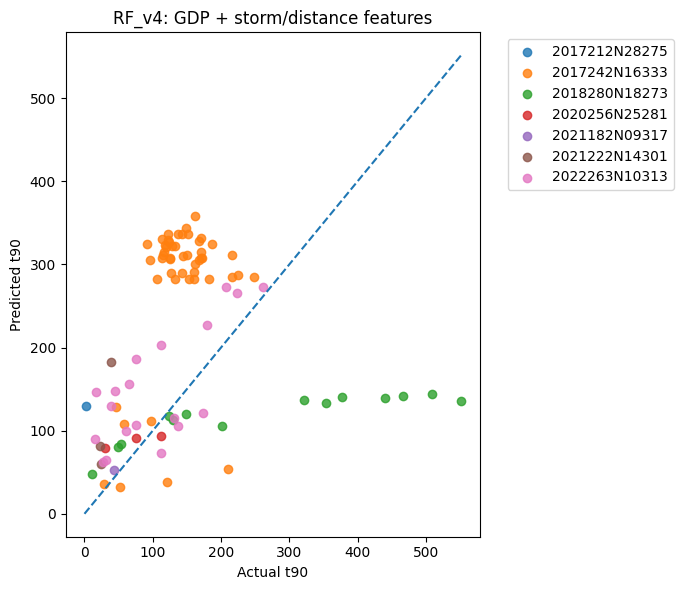

In [10]:
def plot_scatter_by_storm(preds, title):
    plt.figure(figsize=(7, 6))

    for storm in event_df["storm"].unique():
        s = event_df["storm"] == storm
        plt.scatter(
            event_df.loc[s, "t90"],
            preds[s],
            label=storm,
            alpha=0.8
        )

    m = max(event_df["t90"].max(), np.nanmax(preds))
    plt.plot([0, m], [0, m], "--")

    plt.xlabel("Actual t90")
    plt.ylabel("Predicted t90")
    plt.title(title)
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

plot_scatter_by_storm(pred_v4, "RF_v4: GDP + storm/distance features")

pressure_min_7d                    0.321824
storm_max_wind_near_conus_mps      0.193324
mean_gust_7d                       0.172415
max_gust                           0.126810
min_dist_to_storm_km               0.096419
total_precip_7d                    0.067002
county_gdp_real_2017_dollars       0.009991
county_pop                         0.007452
county_gdp_real_2017_per_capita    0.004765
dtype: float64


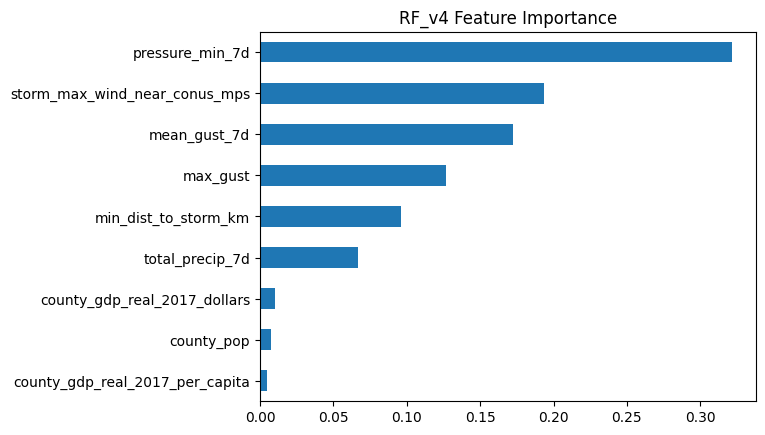

In [11]:
rf_model = model_v4.named_steps["rf"]

feat_imp = pd.Series(
    rf_model.feature_importances_,
    index=features_v4
).sort_values(ascending=False)

print(feat_imp)

feat_imp.plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("RF_v4 Feature Importance")
plt.show()

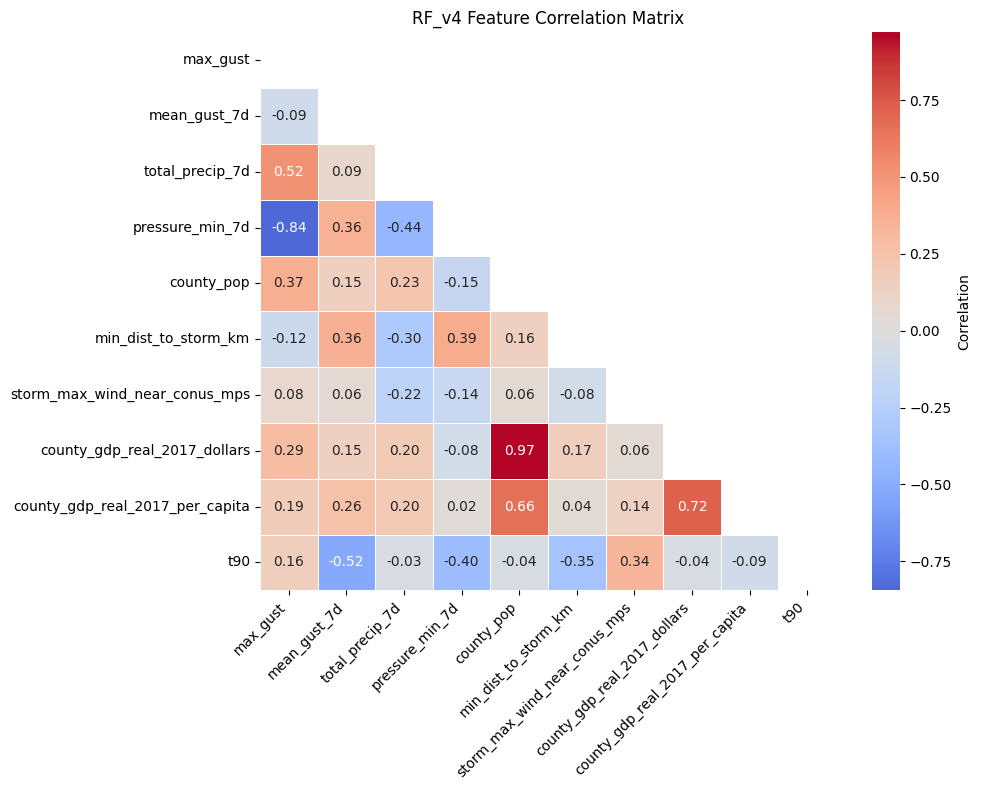

In [12]:
import seaborn as sns

corr_cols = features_v4 + ["t90"]
corr = event_df[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    cbar_kws={"label": "Correlation"}
)

plt.title("RF_v4 Feature Correlation Matrix")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**HYPERPARAMETER TUNING**

Best params found:

***[fill in later]***

In [13]:
# -----------------------
# RF_v4: sensitivity to number of trees
# -----------------------

tree_grid = [100, 200, 500]

results_estimators = []

for n_trees in tree_grid:
    print(f"\nRunning RF_v4 with n_estimators = {n_trees}")
    
    # Rebuild model with different number of trees
    model_temp = Pipeline([
        ("preprocess", preprocess),
        ("rf", RandomForestRegressor(
            n_estimators=n_trees,
            max_depth=None,
            min_samples_leaf=3,
            random_state=42
        ))
    ])
    
    preds_temp, fold_df_temp, mae_temp, rmse_temp = evaluate_logo_global(
        model_temp, X, y, groups
    )
    
    print(f"Global MAE: {mae_temp:.2f}")
    print(f"Global RMSE: {rmse_temp:.2f}")
    
    results_estimators.append({
        "n_estimators": n_trees,
        "MAE": mae_temp,
        "RMSE": rmse_temp
    })

results_estimators_df = pd.DataFrame(results_estimators)

print("\nSummary:")
print(results_estimators_df)


Running RF_v4 with n_estimators = 100
Global MAE: 117.96
Global RMSE: 144.25

Running RF_v4 with n_estimators = 200
Global MAE: 123.97
Global RMSE: 150.21

Running RF_v4 with n_estimators = 500
Global MAE: 124.34
Global RMSE: 150.40

Summary:
   n_estimators         MAE        RMSE
0           100  117.961422  144.249178
1           200  123.970145  150.206515
2           500  124.341249  150.400085


^purely the number of trees doesn't matter much. adding more is worse.

Now for more params:

In [35]:
# -----------------------
# RF_v4 hyperparameter grid
# -----------------------

param_grid = []

# original grid:
# for n_est in [100, 200, 500]:
#     for leaf in [2, 3, 5, 8]:
#         for mf in [0.5, 0.75, 1.0]:
for n_est in [50, 100, 200]:
    for leaf in [2, 4, 6]:
        for mf in [0.2, 0.3, 0.6, 1.0]:
            param_grid.append({
                "n_estimators": n_est,
                "min_samples_leaf": leaf,
                "max_features": mf
            })

print("Total configs:", len(param_grid))

Total configs: 36


In [36]:
def evaluate_rf_config(params, X, y, groups):
    logo = LeaveOneGroupOut()
    
    preds = np.full(len(y), np.nan)
    
    for train_idx, test_idx in logo.split(X, y, groups):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train = y.iloc[train_idx]
        
        model = Pipeline([
            ("preprocess", preprocess),
            ("rf", RandomForestRegressor(
                n_estimators=params["n_estimators"],
                min_samples_leaf=params["min_samples_leaf"],
                max_features=params["max_features"],
                random_state=42
            ))
        ])
        
        model.fit(X_train, y_train)
        preds[test_idx] = model.predict(X_test)
    
    mae = mean_absolute_error(y, preds)
    rmse = np.sqrt(mean_squared_error(y, preds))
    
    return mae, rmse

In [37]:
results = []

for i, params in enumerate(param_grid):
    print(f"{i+1}/{len(param_grid)}", params)
    
    mae, rmse = evaluate_rf_config(params, X, y, groups)
    
    results.append({
        **params,
        "MAE": mae,
        "RMSE": rmse
    })

results_df = pd.DataFrame(results).sort_values("MAE")

print("\nTop 10 configurations:")
print(results_df.head(10))

1/36 {'n_estimators': 50, 'min_samples_leaf': 2, 'max_features': 0.2}
2/36 {'n_estimators': 50, 'min_samples_leaf': 2, 'max_features': 0.3}
3/36 {'n_estimators': 50, 'min_samples_leaf': 2, 'max_features': 0.6}
4/36 {'n_estimators': 50, 'min_samples_leaf': 2, 'max_features': 1.0}
5/36 {'n_estimators': 50, 'min_samples_leaf': 4, 'max_features': 0.2}
6/36 {'n_estimators': 50, 'min_samples_leaf': 4, 'max_features': 0.3}
7/36 {'n_estimators': 50, 'min_samples_leaf': 4, 'max_features': 0.6}
8/36 {'n_estimators': 50, 'min_samples_leaf': 4, 'max_features': 1.0}
9/36 {'n_estimators': 50, 'min_samples_leaf': 6, 'max_features': 0.2}
10/36 {'n_estimators': 50, 'min_samples_leaf': 6, 'max_features': 0.3}
11/36 {'n_estimators': 50, 'min_samples_leaf': 6, 'max_features': 0.6}
12/36 {'n_estimators': 50, 'min_samples_leaf': 6, 'max_features': 1.0}
13/36 {'n_estimators': 100, 'min_samples_leaf': 2, 'max_features': 0.2}
14/36 {'n_estimators': 100, 'min_samples_leaf': 2, 'max_features': 0.3}
15/36 {'n_est

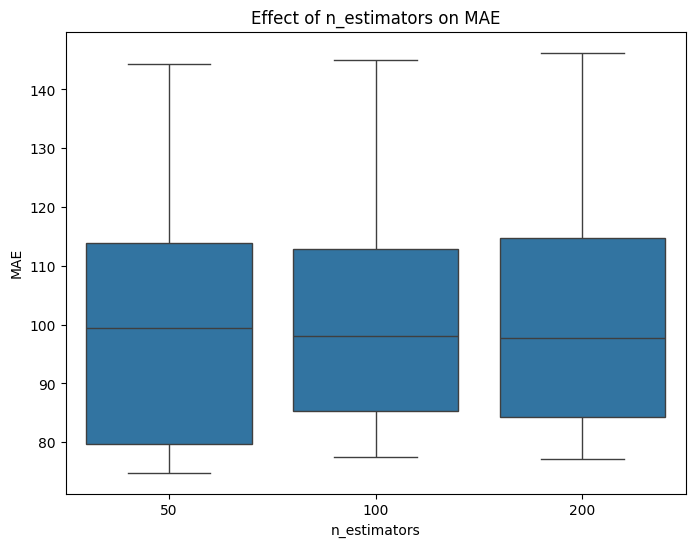

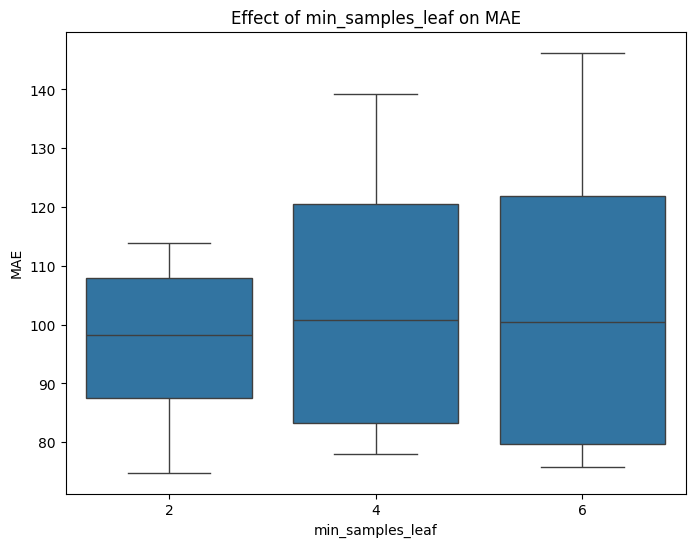

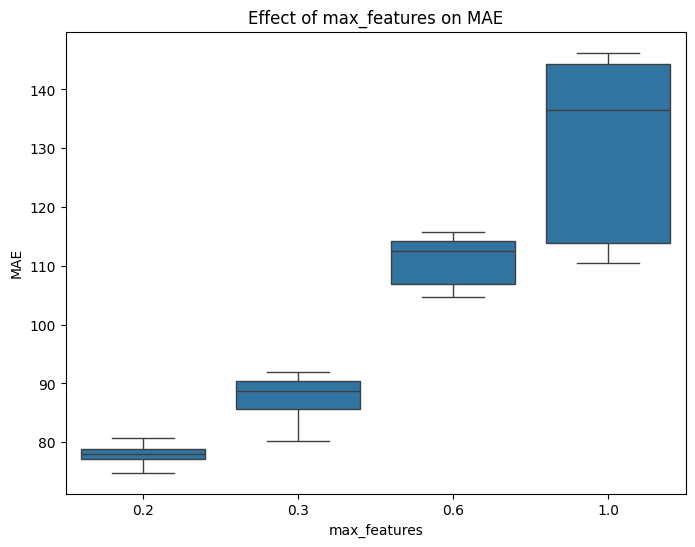

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.boxplot(data=results_df, x="n_estimators", y="MAE")
plt.title("Effect of n_estimators on MAE")
plt.show()

plt.figure(figsize=(8,6))
sns.boxplot(data=results_df, x="min_samples_leaf", y="MAE")
plt.title("Effect of min_samples_leaf on MAE")
plt.show()

plt.figure(figsize=(8,6))
sns.boxplot(data=results_df, x="max_features", y="MAE")
plt.title("Effect of max_features on MAE")
plt.show()

In [39]:
best_row = results_df.iloc[0]

print("Best configuration:")
print(best_row)

print("\nBest MAE:", best_row["MAE"])

Best configuration:
n_estimators         50.000000
min_samples_leaf      2.000000
max_features          0.200000
MAE                  74.826795
RMSE                112.202920
Name: 0, dtype: float64

Best MAE: 74.82679489479219


In [40]:
print("\nTop 5 models:")
print(results_df.head(5))


Top 5 models:
    n_estimators  min_samples_leaf  max_features        MAE        RMSE
0             50                 2           0.2  74.826795  112.202920
8             50                 6           0.2  75.756161  112.560773
32           200                 6           0.2  77.076670  112.361576
12           100                 2           0.2  77.423936  113.088542
4             50                 4           0.2  77.944079  113.377027


In [41]:
print("\nMean MAE by max_features:")
print(results_df.groupby("max_features")["MAE"].mean())

print("\nMean MAE by min_samples_leaf:")
print(results_df.groupby("min_samples_leaf")["MAE"].mean())

print("\nMean MAE by n_estimators:")
print(results_df.groupby("n_estimators")["MAE"].mean())


Mean MAE by max_features:
max_features
0.2     77.844275
0.3     87.655090
0.6    111.044805
1.0    131.534122
Name: MAE, dtype: float64

Mean MAE by min_samples_leaf:
min_samples_leaf
2     96.614999
4    104.296467
6    105.147253
Name: MAE, dtype: float64

Mean MAE by n_estimators:
n_estimators
50     101.039392
100    102.068444
200    102.950883
Name: MAE, dtype: float64


Best model MAE: 77.07667020522122
Best model RMSE: 112.36157564586053


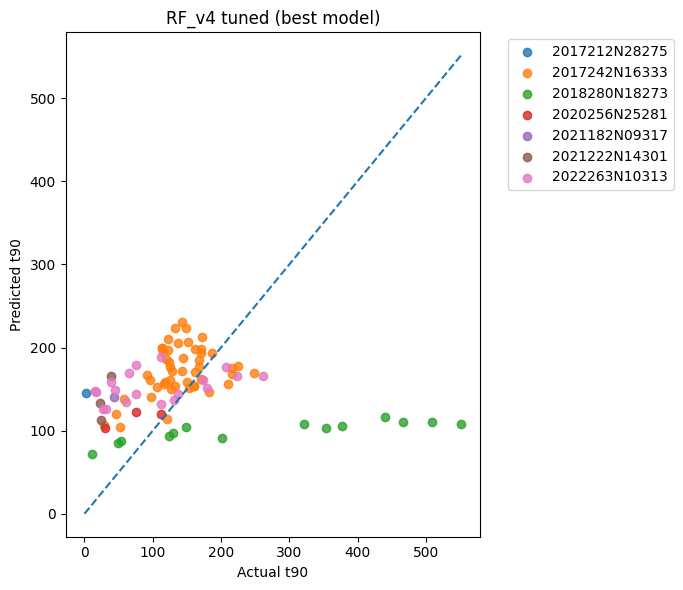

In [42]:
# -----------------------
# Refit best RF model and generate predictions
# -----------------------

# best_params = {
#     "n_estimators": 200,
#     "min_samples_leaf": 5,
#     "max_features": 0.5
# }

best_params = {
    "n_estimators": 200,
    "min_samples_leaf": 6,
    "max_features": 0.2
}

logo = LeaveOneGroupOut()

preds_best = np.full(len(y), np.nan)

for train_idx, test_idx in logo.split(X, y, groups):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train = y.iloc[train_idx]
    
    model_best = Pipeline([
        ("preprocess", preprocess),
        ("rf", RandomForestRegressor(
            n_estimators=best_params["n_estimators"],
            min_samples_leaf=best_params["min_samples_leaf"],
            max_features=best_params["max_features"],
            random_state=42
        ))
    ])
    
    model_best.fit(X_train, y_train)
    preds_best[test_idx] = model_best.predict(X_test)

# Global metrics (sanity check)
print("Best model MAE:", mean_absolute_error(y, preds_best))
print("Best model RMSE:", np.sqrt(mean_squared_error(y, preds_best)))

plot_scatter_by_storm(preds_best, "RF_v4 tuned (best model)")

Very interesting results. Lets see if the randomseed of 42 is just a fluke or if it holds up across different seeds.

In [43]:
# -----------------------
# Test stability across random seeds
# -----------------------

seeds = [0, 1, 2, 42, 100]

results = []

for seed in seeds:
    preds_seed = np.full(len(y), np.nan)

    for train_idx, test_idx in logo.split(X, y, groups):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train = y.iloc[train_idx]

        model_seed = Pipeline([
            ("preprocess", preprocess),
            ("rf", RandomForestRegressor(
                n_estimators=200,
                min_samples_leaf=2,
                max_features=0.2,
                random_state=seed
            ))
        ])

        model_seed.fit(X_train, y_train)
        preds_seed[test_idx] = model_seed.predict(X_test)

    mae = mean_absolute_error(y, preds_seed)
    rmse = np.sqrt(mean_squared_error(y, preds_seed))

    results.append({
        "seed": seed,
        "MAE": mae,
        "RMSE": rmse
    })

results_df = pd.DataFrame(results)

print(results_df)
print("\nMAE range:", results_df["MAE"].min(), "to", results_df["MAE"].max())

   seed        MAE        RMSE
0     0  75.431118  110.253991
1     1  81.277263  114.756756
2     2  80.708933  115.197869
3    42  78.780163  113.065732
4   100  75.305556  110.449399

MAE range: 75.30555635001588 to 81.27726281093096


^ So, relatively stable!

Now trying *SHAP*, fit on full dataset with best params:

In [44]:
# Fit best model on full dataset
model_best = Pipeline([
    ("preprocess", preprocess),
    ("rf", RandomForestRegressor(
        n_estimators=200,
        min_samples_leaf=2,
        max_features=0.2,
        random_state=42
    ))
])

model_best.fit(X, y)

# Get transformed features
X_proc = model_best.named_steps["preprocess"].transform(X)

In [45]:
import shap

rf_model = model_best.named_steps["rf"]

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_proc)


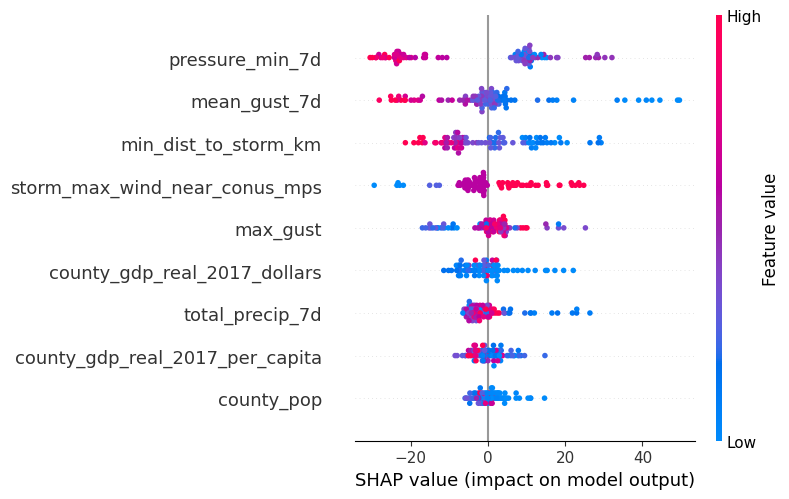

In [46]:
shap.summary_plot(
    shap_values,
    X_proc,
    feature_names=features_v4
)

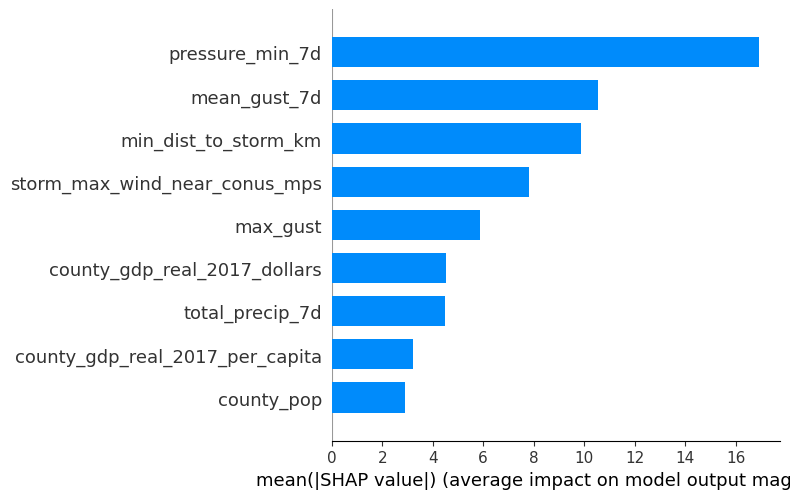

In [47]:
shap.summary_plot(
    shap_values,
    X_proc,
    feature_names=features_v4,
    plot_type="bar"
)

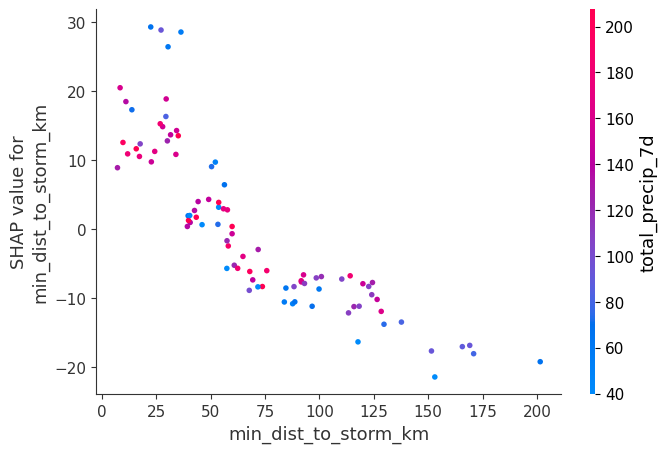

In [48]:
shap.dependence_plot(
    "min_dist_to_storm_km",
    shap_values,
    X_proc,
    feature_names=features_v4
)

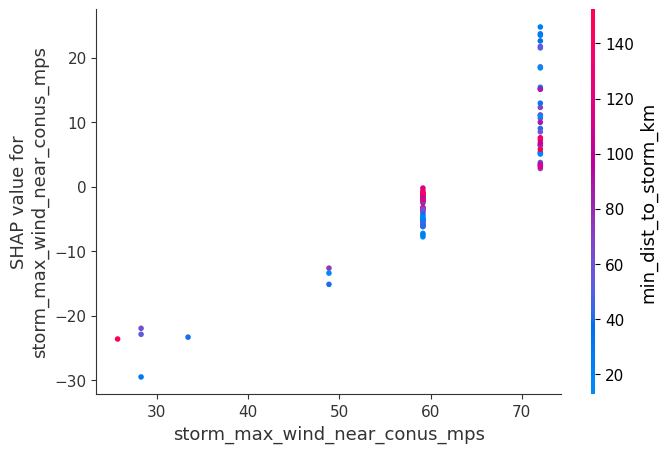

In [49]:
shap.dependence_plot(
    "storm_max_wind_near_conus_mps",
    shap_values,
    X_proc,
    feature_names=features_v4
)

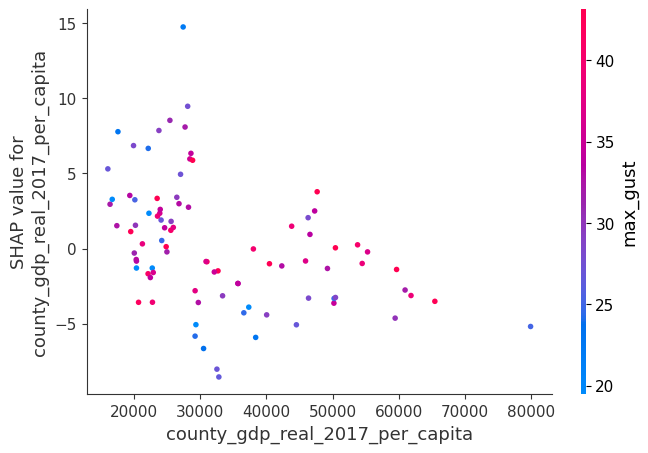

In [50]:
shap.dependence_plot(
    "county_gdp_real_2017_per_capita",
    shap_values,
    X_proc,
    feature_names=features_v4
)

There should not be zero-GDP counties, so this is likely a data issue. 

In [51]:
print("GDP per capita summary:")
print(event_df["county_gdp_real_2017_per_capita"].describe())

print("\nCount of zeros:")
print((event_df["county_gdp_real_2017_per_capita"] == 0).sum())

print("\nCount of NaNs:")
print(event_df["county_gdp_real_2017_per_capita"].isna().sum())

GDP per capita summary:
count       90.000000
mean     33039.130004
std      13422.669431
min      16055.444755
25%      23058.651688
50%      28522.453525
75%      41862.037780
max      79906.070381
Name: county_gdp_real_2017_per_capita, dtype: float64

Count of zeros:
0

Count of NaNs:
0


In [52]:
print(event_df.sort_values("county_gdp_real_2017_per_capita").head(20)[[
    "CountyFIPS",
    "year",
    "county_pop",
    "county_gdp_real_2017_dollars",
    "county_gdp_real_2017_per_capita"
]])

   CountyFIPS  year  county_pop  county_gdp_real_2017_dollars  \
62      12065  2018       15042                  2.415060e+08   
18      12029  2017       17124                  2.806170e+08   
67      12029  2021       17124                  2.862720e+08   
16      12041  2017       18992                  3.307100e+08   
56      12059  2018       19651                  3.454780e+08   
2       12067  2017        7786                  1.508110e+08   
41      12053  2017      206896                  4.036623e+09   
59      12013  2018       13464                  2.683830e+08   
15      12129  2017       35178                  7.052670e+08   
3       12013  2017       13464                  2.710850e+08   
52      12129  2018       35178                  7.113750e+08   
8       12125  2017       15460                  3.144610e+08   
4       12075  2017       45260                  9.221640e+08   
0       12075  2017       45260                  9.221640e+08   
31      12101  2017      

In [53]:
print("Unique GDP values by CountyFIPS:")
print(event_df.groupby("CountyFIPS")["county_gdp_real_2017_dollars"].nunique().describe())

Unique GDP values by CountyFIPS:
count    64.000000
mean      1.390625
std       0.580563
min       1.000000
25%       1.000000
50%       1.000000
75%       2.000000
max       3.000000
Name: county_gdp_real_2017_dollars, dtype: float64


Looking at Hiba's paper and noticed she used R2. Hers is in the log space, so it's much different, but we'll try anywya:

In [55]:
from sklearn.metrics import r2_score
import numpy as np

# --- Global R² (original space) ---
r2_best = r2_score(y, preds_best)

print("Tuned RF_v4 global metrics:")
print("MAE:", mean_absolute_error(y, preds_best))
print("RMSE:", np.sqrt(mean_squared_error(y, preds_best)))
print("R²:", r2_best)

# --- Optional: R² in log space (for comparison with paper) ---
mask = (y > 0) & (preds_best > 0)

r2_log_best = r2_score(np.log(y[mask]), np.log(preds_best[mask]))

print("R² (log space):", r2_log_best)

Tuned RF_v4 global metrics:
MAE: 77.07667020522122
RMSE: 112.36157564586053
R²: -0.163393629404742
R² (log space): -0.1021890581221736


               mean_residual   N  std_residual
storm                                         
2017212N28275    -143.838385   1           NaN
2021222N14301    -108.405275   3     19.106858
2021182N09317     -97.969719   1           NaN
2022263N10313     -47.976836  19     69.354242
2020256N25281     -42.864128   3     32.875872
2017242N16333     -32.687182  49     42.856514
2018280N18273     167.452110  14    175.175292


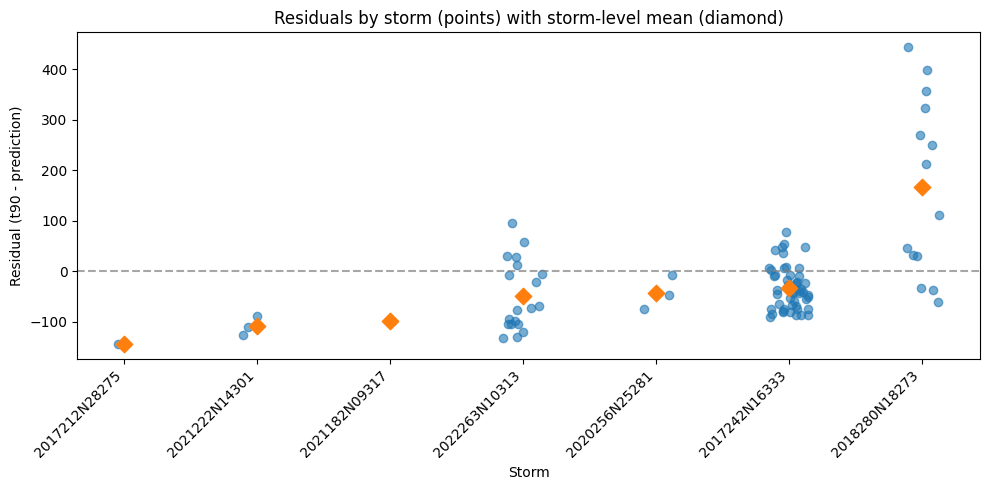

In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Residuals ---
event_df["residual"] = y.values - preds_best

# --- Summary table: mean residual + N ---
storm_summary = (
    event_df
    .groupby("storm")
    .agg(
        mean_residual=("residual", "mean"),
        N=("residual", "size"),
        std_residual=("residual", "std")
    )
    .sort_values("mean_residual")
)

print(storm_summary)

# --- Plot: swarm-like scatter + mean marker ---
# (manual jitter to avoid extra deps)
storms = storm_summary.index.tolist()
storm_to_x = {s: i for i, s in enumerate(storms)}

x = event_df["storm"].map(storm_to_x).astype(float).values
jitter = np.random.uniform(-0.15, 0.15, size=len(x))
x_jittered = x + jitter
y_res = event_df["residual"].values

plt.figure(figsize=(10, 5))
plt.scatter(x_jittered, y_res, alpha=0.6)

# Mean marker per storm
means = storm_summary["mean_residual"].values
xs = np.arange(len(storms))
plt.scatter(xs, means, marker="D", s=70)  # diamond for mean

# Horizontal zero line
plt.axhline(0, color='grey', linestyle='--', alpha=0.7)

plt.xticks(xs, storms, rotation=45, ha="right")
plt.xlabel("Storm")
plt.ylabel("Residual (t90 - prediction)")
plt.title("Residuals by storm (points) with storm-level mean (diamond)")

plt.tight_layout()
plt.show()

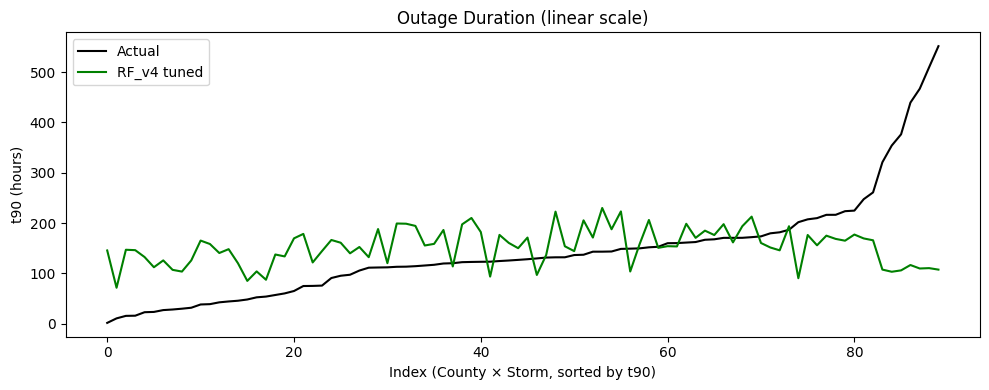

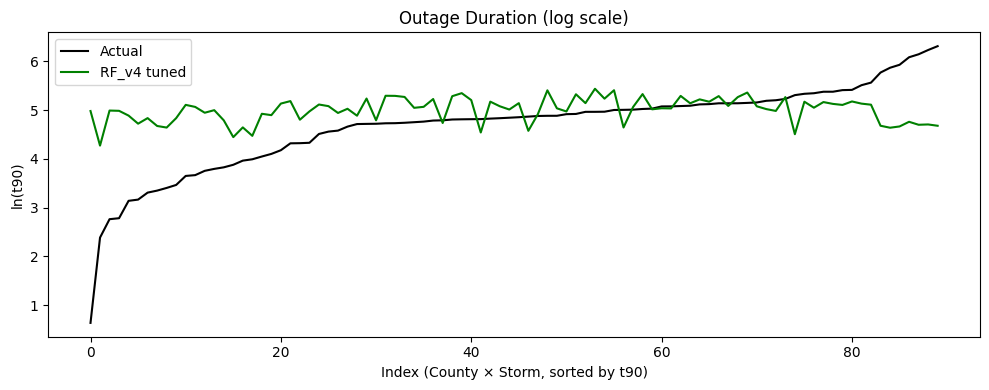

In [62]:
import numpy as np
import matplotlib.pyplot as plt

# --- Prepare sorted data ---
# Sort by actual t90 (ascending)
order = np.argsort(y.values)

y_sorted = y.values[order]
pred_sorted = preds_best[order]

x = np.arange(len(y_sorted))

# --- Plot 1: Linear scale ---
plt.figure(figsize=(10, 4))
plt.plot(x, y_sorted, color="black", label="Actual")
plt.plot(x, pred_sorted, color="green", label="RF_v4 tuned")

plt.xlabel("Index (County × Storm, sorted by t90)")
plt.ylabel("t90 (hours)")
plt.title("Outage Duration (linear scale)")
plt.legend()

plt.tight_layout()
plt.show()


# --- Plot 2: Log scale ---

y_log = np.log(y_sorted)
pred_log = np.log(pred_sorted)
x_log = np.arange(len(y_log))

plt.figure(figsize=(10, 4))
plt.plot(x_log, y_log, color="black", label="Actual")
plt.plot(x_log, pred_log, color="green", label="RF_v4 tuned")

plt.xlabel("Index (County × Storm, sorted by t90)")
plt.ylabel("ln(t90)")
plt.title("Outage Duration (log scale)")
plt.legend()

plt.tight_layout()
plt.show()

What happens if we just estimate the mean using LOSO? (doesn't just do y.mean() to avoid leakage, but does it on the training folds)

LOSO Mean Baseline:
MAE: 72.75283507725612
RMSE: 109.90306087966582
R²: -0.11303959982435474


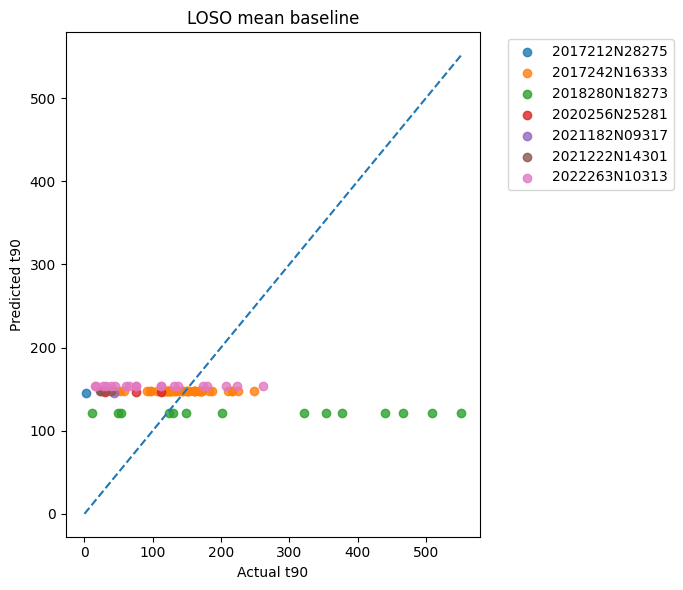

In [63]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

logo = LeaveOneGroupOut()

preds_mean = np.full(len(y), np.nan)

for train_idx, test_idx in logo.split(X, y, groups):
    y_train = y.iloc[train_idx]
    
    # Mean of training data only (important!)
    train_mean = y_train.mean()
    
    preds_mean[test_idx] = train_mean

# --- Global metrics ---
mae_mean = mean_absolute_error(y, preds_mean)
rmse_mean = np.sqrt(mean_squared_error(y, preds_mean))

print("LOSO Mean Baseline:")
print("MAE:", mae_mean)
print("RMSE:", rmse_mean)

# --- Optional: R² (for comparison) ---
from sklearn.metrics import r2_score

r2_mean = r2_score(y, preds_mean)
print("R²:", r2_mean)

# --- Plot ---
plot_scatter_by_storm(preds_mean, "LOSO mean baseline")

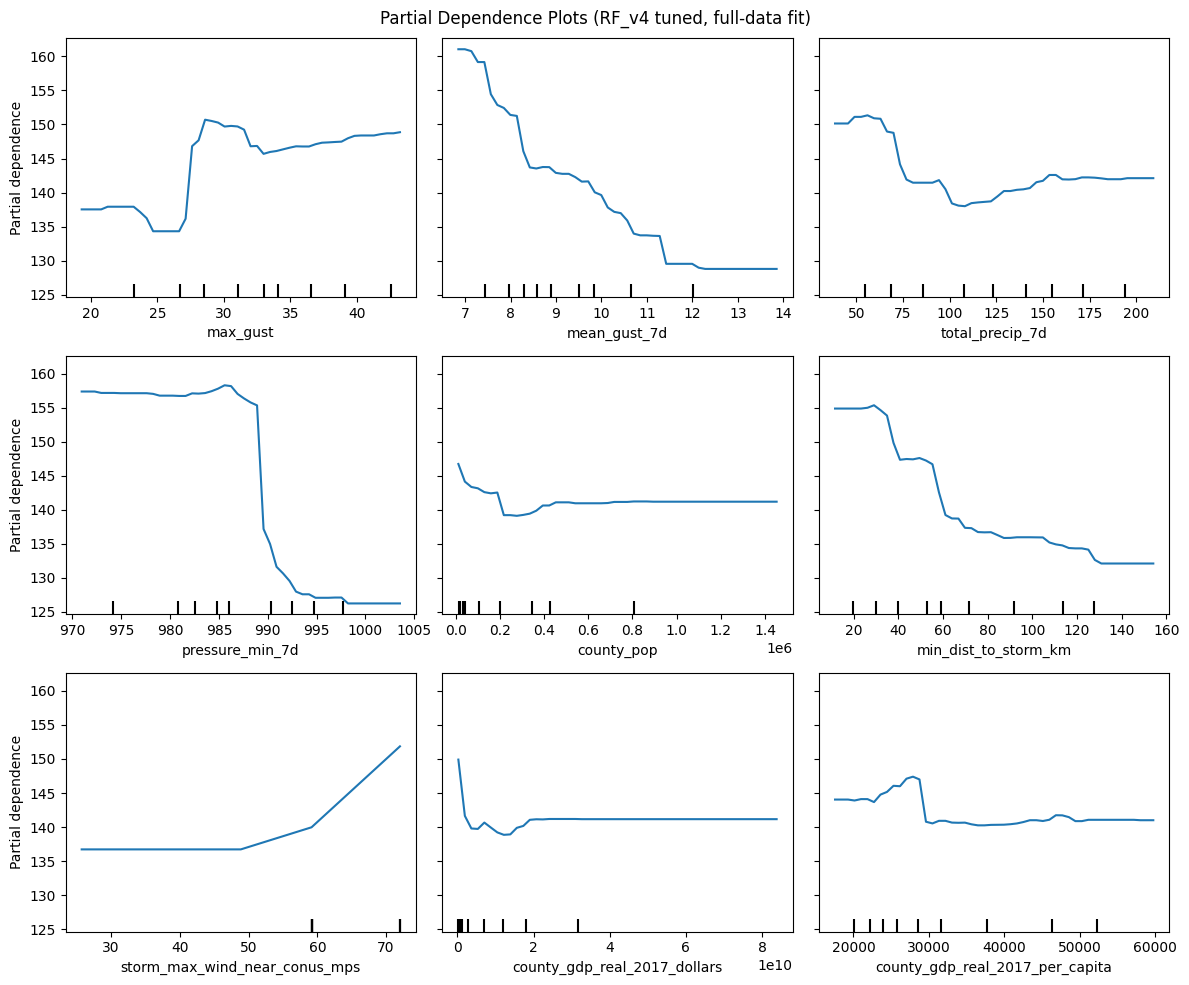

In [65]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

# --- Fit final model on full data (for interpretation only) ---

X_float = X.astype(float)

model_full = Pipeline([
    ("preprocess", preprocess),
    ("rf", RandomForestRegressor(
        n_estimators=200,
        min_samples_leaf=6,
        max_features=0.2,
        random_state=42
    ))
])

model_full.fit(X, y)

# --- PDP plots ---
fig, ax = plt.subplots(3, 3, figsize=(12, 10))

model_full.fit(X_float, y)

PartialDependenceDisplay.from_estimator(
    model_full,
    X_float,
    features=features_v4,
    grid_resolution=50,
    ax=ax
)

plt.suptitle("Partial Dependence Plots (RF_v4 tuned, full-data fit)")
plt.tight_layout()
plt.show()